#  Heart Disease Prediction using Machine Learning

This notebook presents an end-to-end machine learning pipeline for predicting the **presence or absence of heart disease** using a kaggle dataset.  



## Importing Required Libraries

The following libraries are used throughout the notebook for data manipulation, numerical computation, visualization, and exploratory data analysis:

- **Pandas** and **NumPy** for data handling and numerical operations
- **Matplotlib** and **Seaborn** for creating statistical visualizations and plots

These libraries form the foundation for efficient data analysis and model development in Python.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

##  Loading the Dataset

The training dataset is loaded using **Pandas**.  
This dataset contains clinical and diagnostic attributes of patients along with the target variable indicating the **presence or absence of heart disease**.

All subsequent analysis, preprocessing, and modeling steps are performed on this dataset.


In [3]:
df = pd.read_csv('train.csv')

In [4]:
df

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
629995,629995,56,0,1,110,226,0,0,132,0,0.0,1,0,7,Absence
629996,629996,54,1,4,128,249,1,2,150,0,0.0,2,0,3,Absence
629997,629997,67,1,4,130,275,0,0,149,0,0.0,1,2,7,Presence
629998,629998,52,1,4,140,199,0,2,157,0,0.0,1,0,6,Presence


In [5]:
df.head(5)

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


#### Knowing the shape of the dataset

In [6]:
df.shape

(630000, 15)

### Information of the Dataset

In [7]:
df.describe()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,314999.500000,54.136706,0.714735,3.312752,130.497433,245.011814,0.079987,0.981660,152.816763,0.273725,0.716028,1.455871,0.451040,4.618873
std,181865.479132,8.256301,0.451541,0.851615,14.975802,33.681581,0.271274,0.998783,19.112927,0.445870,0.948472,0.545192,0.798549,1.950007
min,0.000000,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000
25%,157499.750000,48.000000,0.000000,3.000000,120.000000,223.000000,0.000000,0.000000,142.000000,0.000000,0.000000,1.000000,0.000000,3.000000
50%,314999.500000,54.000000,1.000000,4.000000,130.000000,243.000000,0.000000,0.000000,157.000000,0.000000,0.100000,1.000000,0.000000,3.000000
75%,472499.250000,60.000000,1.000000,4.000000,140.000000,269.000000,0.000000,2.000000,166.000000,1.000000,1.400000,2.000000,1.000000,7.000000
max,629999.000000,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Age                      630000 non-null  int64  
 2   Sex                      630000 non-null  int64  
 3   Chest pain type          630000 non-null  int64  
 4   BP                       630000 non-null  int64  
 5   Cholesterol              630000 non-null  int64  
 6   FBS over 120             630000 non-null  int64  
 7   EKG results              630000 non-null  int64  
 8   Max HR                   630000 non-null  int64  
 9   Exercise angina          630000 non-null  int64  
 10  ST depression            630000 non-null  float64
 11  Slope of ST              630000 non-null  int64  
 12  Number of vessels fluro  630000 non-null  int64  
 13  Thallium                 630000 non-null  int64  
 14  Hear

## Target Variable Encoding

The target variable **Heart Disease** is categorical in nature, with values indicating the *presence* or *absence* of heart disease.

For compatibility with machine learning algorithms, it is converted into a binary numerical format:

- **Absence → 0**
- **Presence → 1**

This binary representation allows the problem to be treated as a standard **binary classification task**.


In [9]:
df["Heart_disease_bin"] = df["Heart Disease"].map({"Absence":0,"Presence":1})


In [10]:
df.columns

Index(['id', 'Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol',
       'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina',
       'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium',
       'Heart Disease', 'Heart_disease_bin'],
      dtype='object')

In [11]:
df = df.drop(columns=["id"])

## Target Variable Distribution

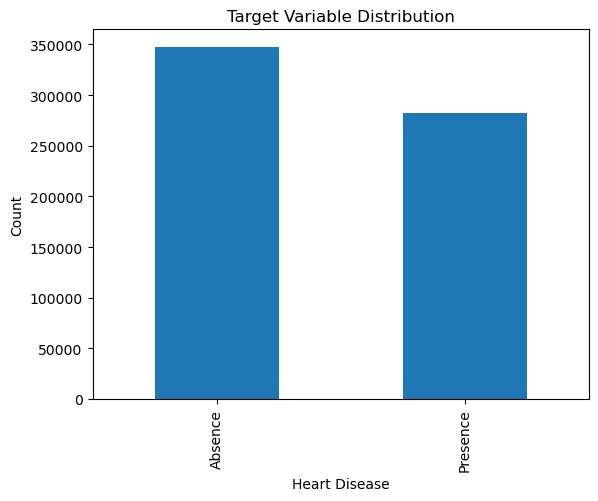

In [12]:
plt.figure()
df["Heart Disease"].value_counts().plot(kind="bar")
plt.title("Target Variable Distribution")
plt.xlabel("Heart Disease")
plt.ylabel("Count")
plt.show()


## Numerical Feature Distributions (Univariate)

### Age

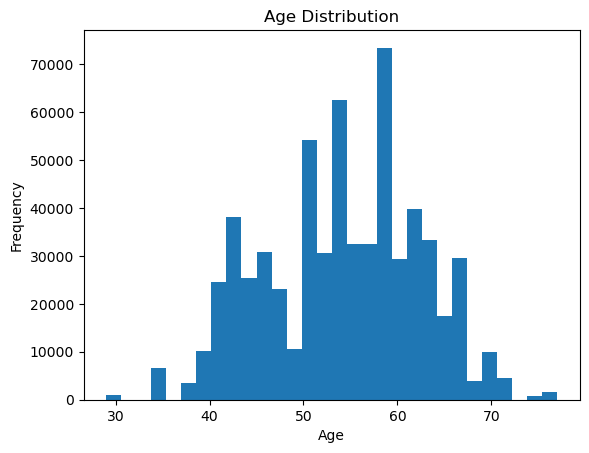

In [13]:
plt.figure()
plt.hist(df["Age"], bins=30)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()


### Blood Pressure


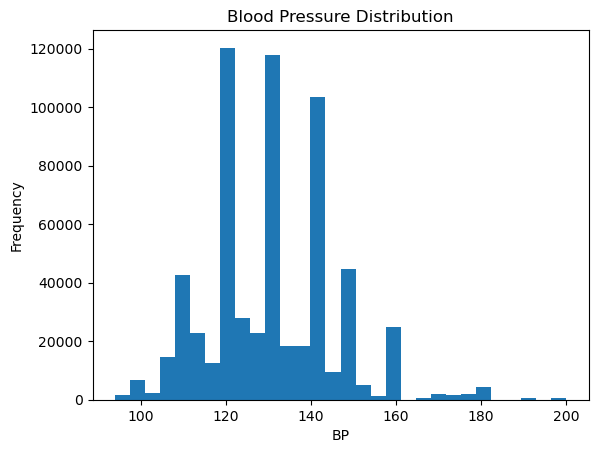

In [14]:
plt.figure()
plt.hist(df["BP"], bins=30)
plt.title("Blood Pressure Distribution")
plt.xlabel("BP")
plt.ylabel("Frequency")
plt.show()


### Cholestrol

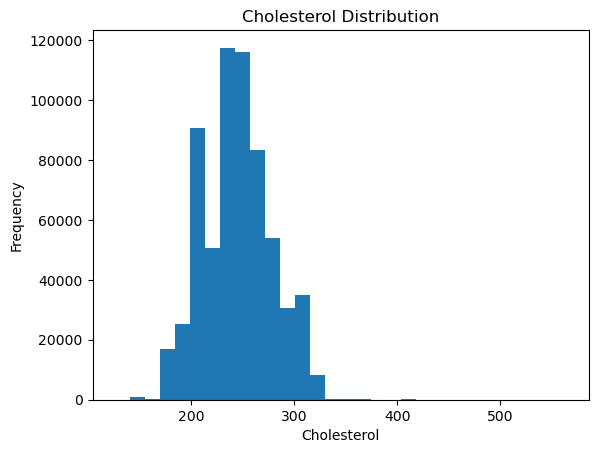

In [15]:
plt.figure()
plt.hist(df["Cholesterol"], bins=30)
plt.title("Cholesterol Distribution")
plt.xlabel("Cholesterol")
plt.ylabel("Frequency")
plt.show()


### Max Heart Rate

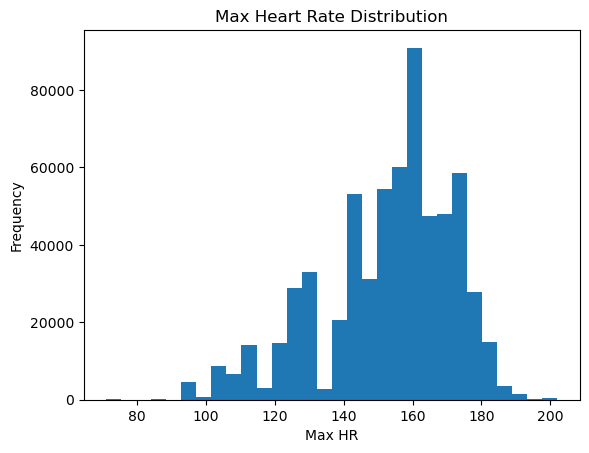

In [16]:
plt.figure()
plt.hist(df["Max HR"], bins=30)
plt.title("Max Heart Rate Distribution")
plt.xlabel("Max HR")
plt.ylabel("Frequency")
plt.show()


### ST Depression

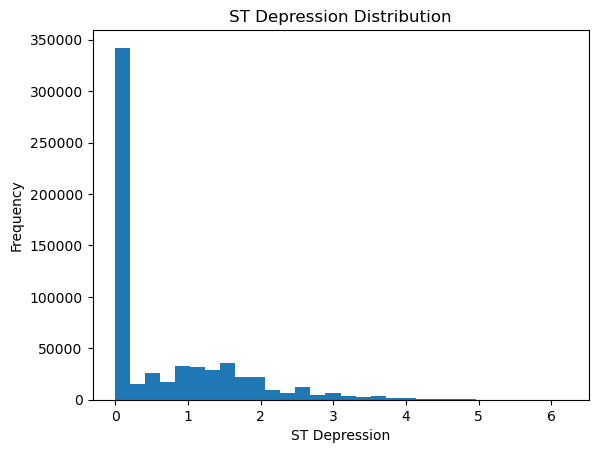

In [17]:
plt.figure()
plt.hist(df["ST depression"], bins=30)
plt.title("ST Depression Distribution")
plt.xlabel("ST Depression")
plt.ylabel("Frequency")
plt.show()


# Categorical Features vs Target (Bar Plots)

### Chest Pain Type vs Heart Disease

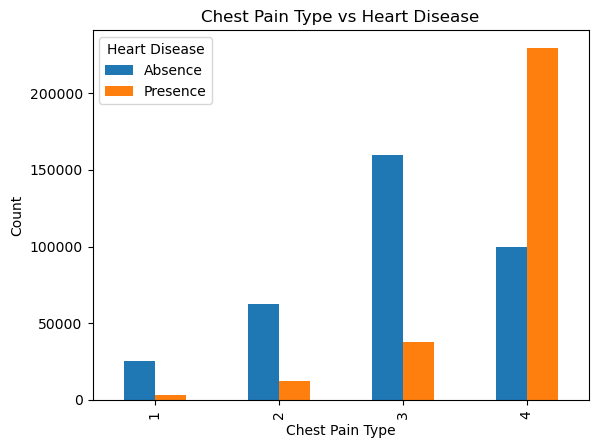

In [18]:
pd.crosstab(df["Chest pain type"], df["Heart Disease"]).plot(kind="bar")
plt.title("Chest Pain Type vs Heart Disease")
plt.xlabel("Chest Pain Type")
plt.ylabel("Count")
plt.show()


### Exercise Angina vs Heart Disease

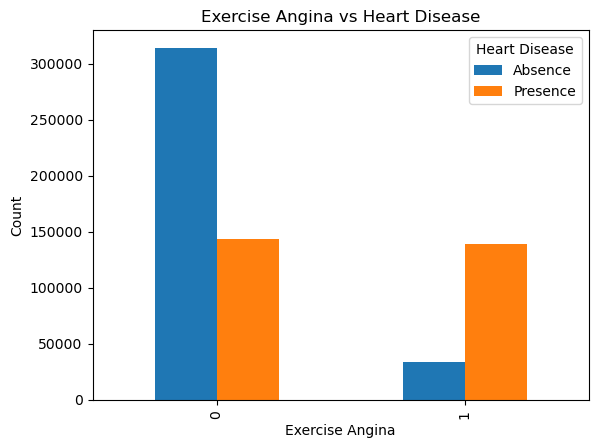

In [19]:
pd.crosstab(df["Exercise angina"], df["Heart Disease"]).plot(kind="bar")
plt.title("Exercise Angina vs Heart Disease")
plt.xlabel("Exercise Angina")
plt.ylabel("Count")
plt.show()


### Sex vs Heart Disease

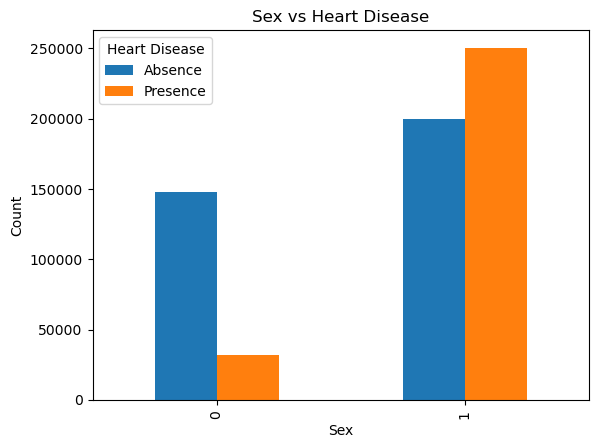

In [20]:
pd.crosstab(df["Sex"], df["Heart Disease"]).plot(kind="bar")
plt.title("Sex vs Heart Disease")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.show()


# Numerical Features vs Target (Boxplots)

### Age vs Heart Disease

<Figure size 640x480 with 0 Axes>

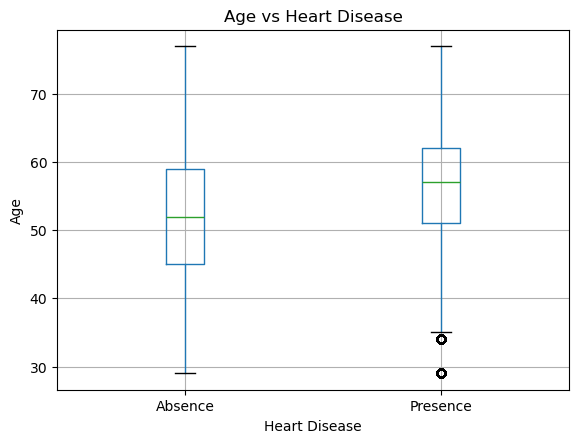

In [21]:
plt.figure()
df.boxplot(column="Age", by="Heart Disease")
plt.title("Age vs Heart Disease")
plt.suptitle("")
plt.xlabel("Heart Disease")
plt.ylabel("Age")
plt.show()


### Max HR vs Heart Disease

<Figure size 640x480 with 0 Axes>

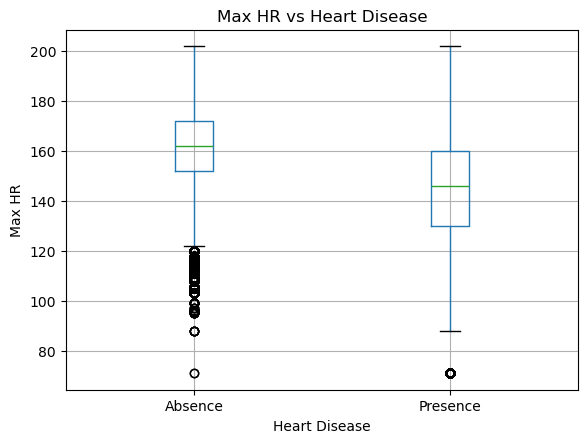

In [22]:
plt.figure()
df.boxplot(column="Max HR", by="Heart Disease")
plt.title("Max HR vs Heart Disease")
plt.suptitle("")
plt.xlabel("Heart Disease")
plt.ylabel("Max HR")
plt.show()


### ST Depression vs Heart Disease

<Figure size 640x480 with 0 Axes>

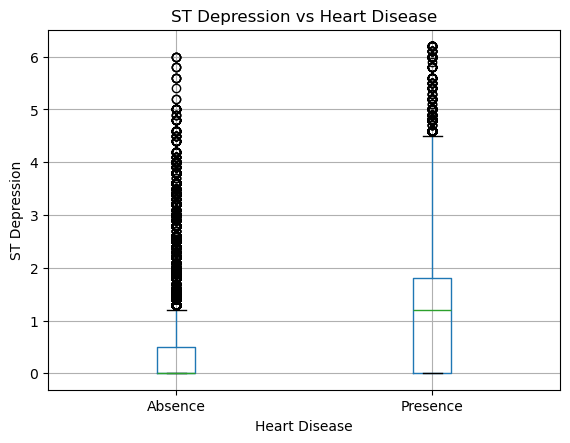

In [23]:
plt.figure()
df.boxplot(column="ST depression", by="Heart Disease")
plt.title("ST Depression vs Heart Disease")
plt.suptitle("")
plt.xlabel("Heart Disease")
plt.ylabel("ST Depression")
plt.show()


# Correlation Heatmap (Numerical Only)

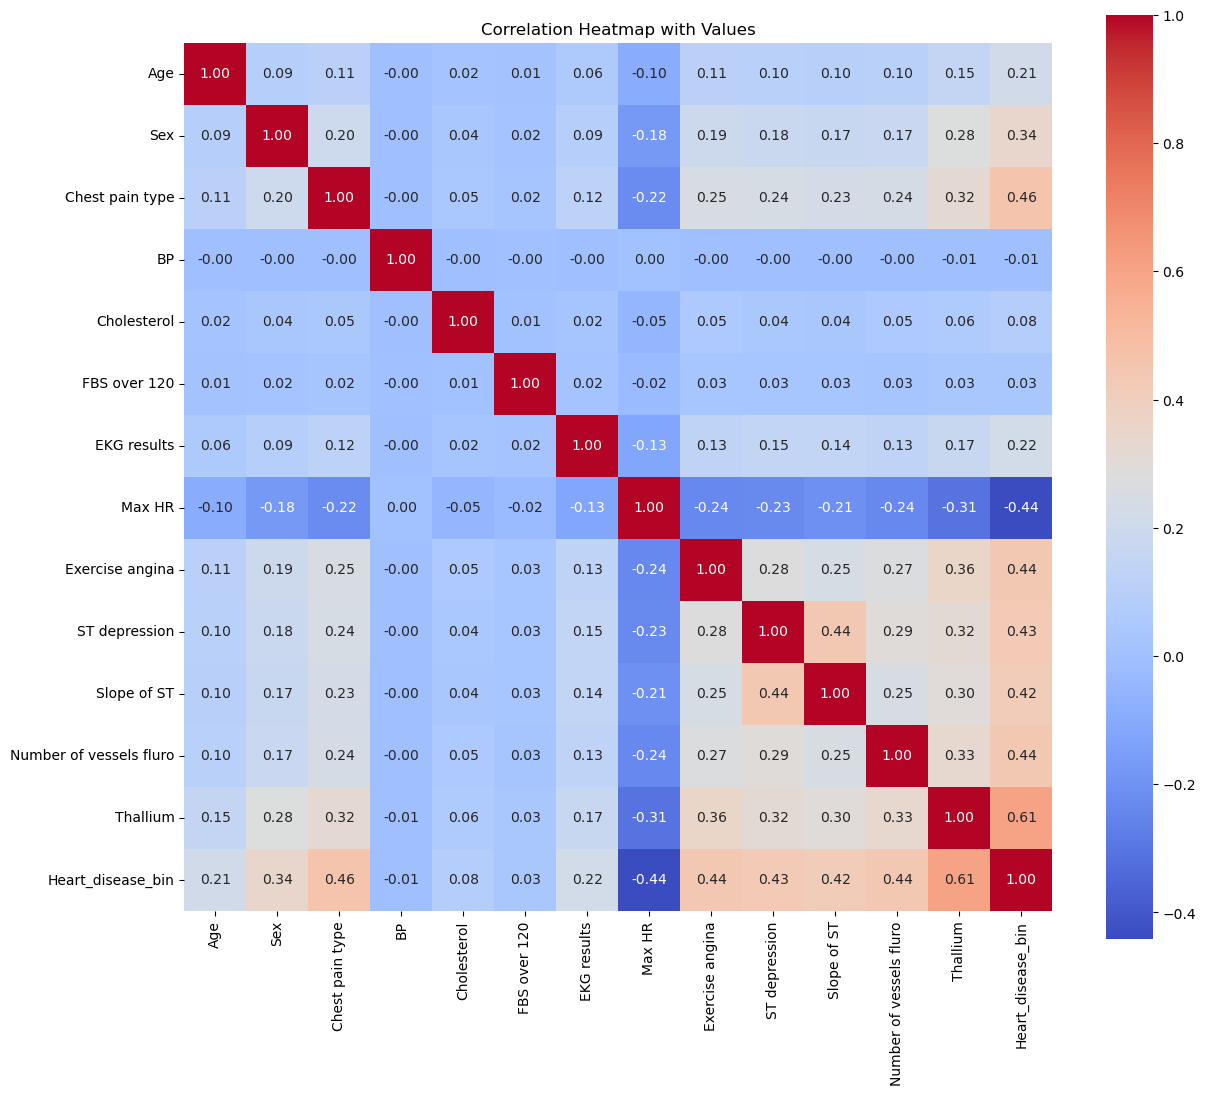

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

# Drop original string target
df_corr = df.drop(columns=["Heart Disease"])

corr = df_corr.corr()

plt.figure(figsize=(14, 12))
sns.heatmap(
    corr,
    annot=True,          # <-- shows numbers
    fmt=".2f",           # 2 decimal places
    cmap="coolwarm",
    square=True
)
plt.title("Correlation Heatmap with Values")
plt.show()


<Axes: >

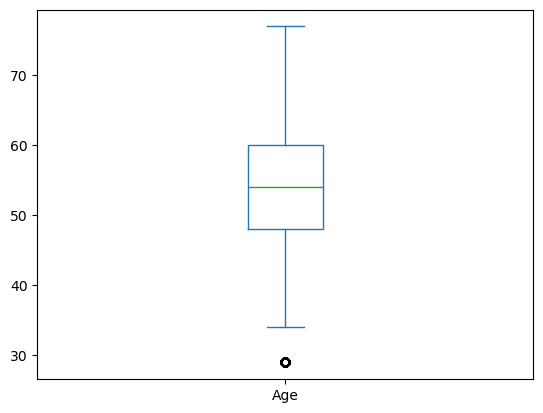

In [25]:
df["Age"].plot(kind="box")

## Univariate Distribution Analysis

To understand the individual behavior of numerical features, histograms with **Kernel Density Estimation (KDE)** are plotted.

This analysis helps in:
- Identifying the overall distribution shape (normal or skewed)
- Detecting outliers and extreme values
- Understanding whether feature transformations may be required

The following continuous features are analyzed:
- Age  
- Blood Pressure (BP)  
- Cholesterol  
- Maximum Heart Rate  
- ST Depression  

KDE curves provide a smooth estimate of the probability density, making it easier to visually assess skewness and normality.


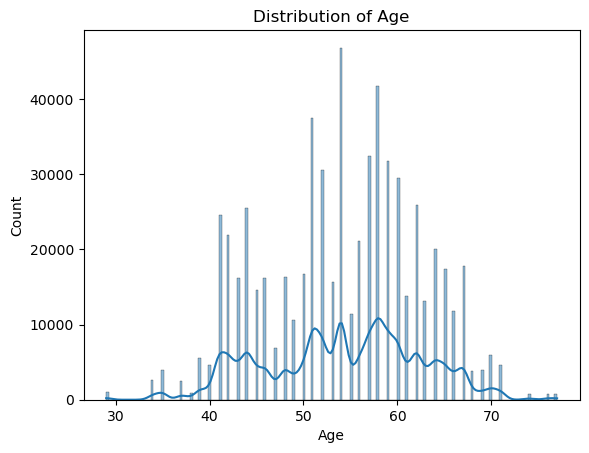

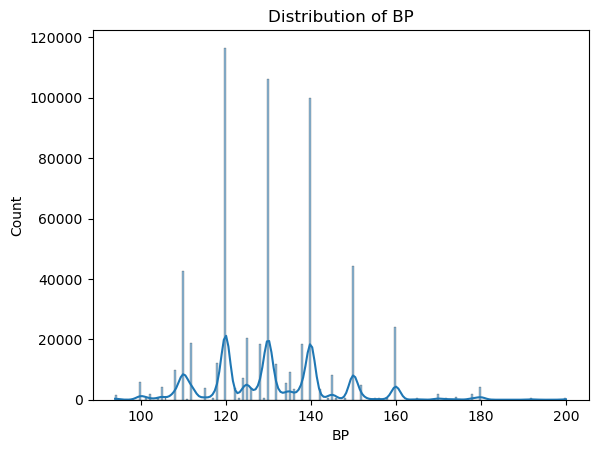

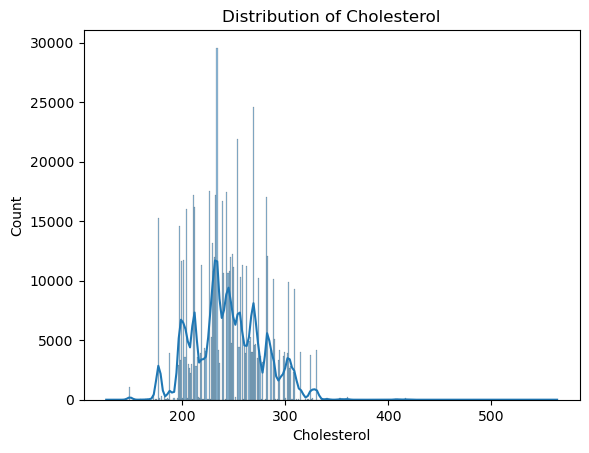

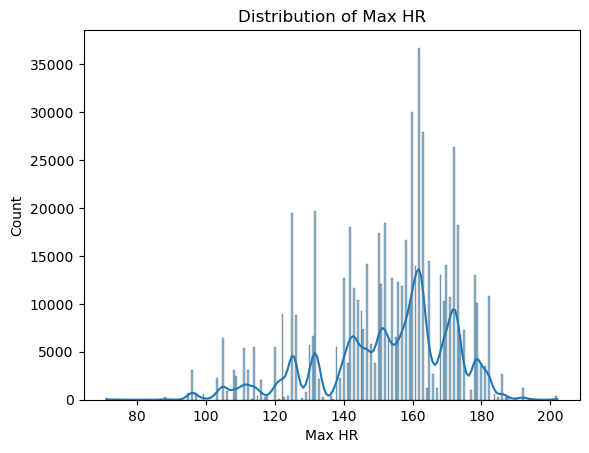

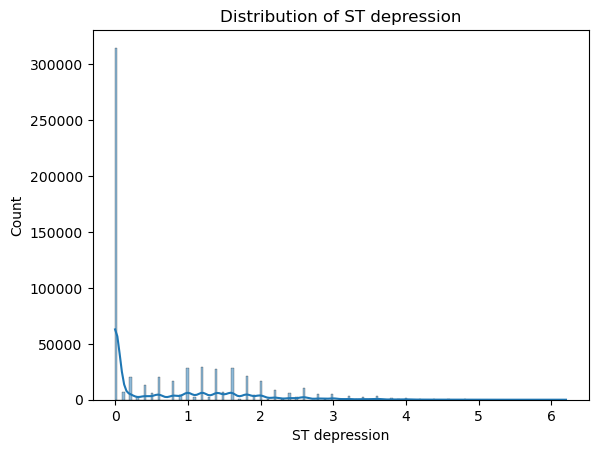

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

num_features = ["Age", "BP", "Cholesterol", "Max HR", "ST depression"]

for col in num_features:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()


## Multicollinearity Analysis using Variance Inflation Factor (VIF)

Medical datasets often contain **clinically interrelated features** (e.g., Age, Blood Pressure, Cholesterol), which can lead to multicollinearity.

To quantify this effect, **Variance Inflation Factor (VIF)** is calculated for each numerical feature.  
VIF measures how well a feature can be explained by all other features combined.

Interpretation guidelines:
- **VIF ≈ 1** → No multicollinearity
- **VIF between 1 and 5** → Low multicollinearity
- **VIF between 5 and 10** → Moderate multicollinearity
- **VIF > 10** → High multicollinearity

Although several features exhibit high VIF values, this behavior is expected and clinically meaningful in medical data.  
No features are removed solely based on VIF, as tree-based models are robust to correlated predictors.


In [27]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import numpy as np
import pandas as pd


X = df[
    [
        "Age", "Sex", "Chest pain type", "BP", "Cholesterol",
        "FBS over 120", "EKG results", "Max HR",
        "Exercise angina", "ST depression",
        "Slope of ST", "Number of vessels fluro", "Thallium"
    ]
].astype(float)

vif_df = pd.DataFrame()
vif_df["Feature"] = X.columns
vif_df["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif_df.sort_values(by="VIF", ascending=False)


,Feature,VIF
3,BP,56.627461
7,Max HR,49.186843
4,Cholesterol,44.416204
0,Age,39.219069
2,Chest pain type,18.483402
10,Slope of ST,10.566640
12,Thallium,9.313990
1,Sex,3.924358
9,ST depression,2.155124
6,EKG results,2.071019


##### This is a medical data and thus even the columns are having coolinearity >10 still we will not drop them  as the data is crucial thus we will be using a model that:

1. Do not assume feature independence
2. Are robust to multicollinearity
3. Capture non-linear interactions

## Train–Test Split

Before training machine learning models, the dataset is split into **training** and **testing** subsets.

Key considerations:
- The target variable is separated from the feature set
- Non-informative columns such as identifiers are removed


An 80–20 split is used:
- **80%** for model training
- **20%** for unbiased model evaluation

Stratification (grouping) is particularly important in medical datasets to ensure that both classes (presence and absence of disease) are adequately represented.


In [28]:
from sklearn.model_selection import train_test_split




y = df["Heart_disease_bin"]
X = df.drop(columns=["Heart Disease","Heart_disease_bin", "id"], errors="ignore")


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


In [29]:
X_train

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
539041,48,1,4,140,249,0,2,144,0,2.5,2,1,7
211140,61,1,3,130,208,0,0,174,0,1.6,2,0,3
325129,69,1,4,130,226,0,0,132,1,1.4,2,0,6
91177,67,1,4,140,269,0,2,182,1,1.2,1,3,3
346105,48,1,3,120,275,0,0,171,1,0.4,1,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
252454,48,1,4,150,197,0,0,160,0,0.0,1,0,3
273991,51,1,4,120,222,0,2,125,0,0.8,1,0,7
88920,44,1,4,145,204,0,2,158,0,0.8,1,0,7
513771,58,1,3,136,282,0,0,179,0,1.4,1,3,7


## Removing Non-Feature Columns

Before proceeding further, non-feature columns are removed from the dataset to ensure that only meaningful input variables are used for modeling.

The following columns are excluded:
- **Target variables** (original and encoded forms)
- **Identifier column (id)**, which carries no predictive information

The errors="ignore" parameter is used as a safety measure to prevent runtime errors if any column is already removed in earlier steps.

Moreover I added this step as was having a redundancy in one variable which was creating confusion. Thus to prevent any error this is used


In [30]:
df.drop(columns=["Heart Disease", "Heart_Disease_bin","Heart_disease_bin", "id"], errors="ignore")

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
0,58,1,4,152,239,0,0,158,1,3.6,2,2,7
1,52,1,1,125,325,0,2,171,0,0.0,1,0,3
2,56,0,2,160,188,0,2,151,0,0.0,1,0,3
3,44,0,3,134,229,0,2,150,0,1.0,2,0,3
4,58,1,4,140,234,0,2,125,1,3.8,2,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
629995,56,0,1,110,226,0,0,132,0,0.0,1,0,7
629996,54,1,4,128,249,1,2,150,0,0.0,2,0,3
629997,67,1,4,130,275,0,0,149,0,0.0,1,2,7
629998,52,1,4,140,199,0,2,157,0,0.0,1,0,6


## Baseline Model: Random Forest Classifier

A **Random Forest classifier** is used as the baseline model for this task.

### Why Random Forest?
- Robust to **multicollinearity**
- Captures **non-linear relationships**
- Requires minimal preprocessing
- Performs well on structured medical datasets

The model is trained on the training set and evaluated on the hold-out test set.

### Evaluation Metrics:
- **ROC-AUC** is used as the primary metric
- **Classification report** provides precision, recall, and F1-score
- **Confusion matrix** helps analyze false positives and false negatives

This baseline serves as a reference point for more advanced boosting and ensembling models.


In [31]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

rf = RandomForestClassifier( n_estimators=200,max_depth=None,random_state=42,n_jobs=-1)
   
rf.fit(X_train, y_train)

# Predictions
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

# Evaluation
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))


ROC-AUC: 0.9482378793249251
              precision    recall  f1-score   support

           0       0.89      0.90      0.89     69509
           1       0.87      0.86      0.87     56491

    accuracy                           0.88    126000
   macro avg       0.88      0.88      0.88    126000
weighted avg       0.88      0.88      0.88    126000

[[62507  7002]
 [ 7843 48648]]


## Saving the Trained Model

The trained Random Forest model is saved to disk using **Joblib**.

Saving the model allows:
- Reuse of the trained model without retraining
- Faster inference during deployment or future evaluation
- Easy sharing and reproducibility of results

The model is stored as a serialized file (`.pkl`) that can be loaded later for predictions or further analysis.


In [32]:
import joblib
joblib.dump(rf, "trained_model.pkl")

['trained_model.pkl']

### Which feature is contributing how much 

In [33]:
rf.feature_importances_

array([0.07546019, 0.02663857, 0.13754266, 0.06079159, 0.08636553,
       0.00519418, 0.01117504, 0.13028691, 0.06376245, 0.07434733,
       0.05208273, 0.07820438, 0.19814845])

In [34]:

X_train.columns

Index(['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120',
       'EKG results', 'Max HR', 'Exercise angina', 'ST depression',
       'Slope of ST', 'Number of vessels fluro', 'Thallium'],
      dtype='object')

## Gradient Boosting Classifier

To improve upon the Random Forest baseline, a **Gradient Boosting Classifier** is trained.

### Need of Gradient Boosting
- Builds trees **sequentially**, correcting errors of previous trees
- Focuses on **hard-to-classify cases**
- Captures complex **non-linear interactions**
- Often improves recall for minority classes in medical datasets

A conservative learning rate and shallow trees are used to reduce overfitting while maintaining strong predictive performance.

### Evaluation
Model performance is evaluated using:
- ROC-AUC score
- Classification report
- Confusion matrix

This model serves as a stepping stone toward more advanced gradient boosting frameworks.


In [36]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb.fit(X_train, y_train) 

# Predictions
y_pred_gb = gb.predict(X_test)
y_prob_gb = gb.predict_proba(X_test)[:, 1]

# Evaluation
print("ROC-AUC:", roc_auc_score(y_test, y_prob_gb))
print(classification_report(y_test, y_pred_gb))
print(confusion_matrix(y_test, y_pred_gb))


ROC-AUC: 0.9545421752727887
              precision    recall  f1-score   support

           0       0.89      0.91      0.90     69509
           1       0.88      0.87      0.87     56491

    accuracy                           0.89    126000
   macro avg       0.89      0.89      0.89    126000
weighted avg       0.89      0.89      0.89    126000

[[62960  6549]
 [ 7558 48933]]


## Extreme Gradient Boosting (XGBoost)

To further enhance model performance, **XGBoost**, an optimized and regularized gradient boosting framework, is applied.

### XGBoost
- Designed for **large-scale tabular data**
- Handles **non-linear feature interactions** effectively
- Robust to **multicollinearity**
- Incorporates **regularization** to prevent overfitting


### Key Configuration Highlights:
- A **low learning rate** with a higher number of trees for stable learning
- Controlled tree depth to balance bias and variance
- Subsampling of rows and features to improve generalization
- Regularization parameters to stabilize learning on correlated medical features
- ROC-AUC used as the primary evaluation metric

This model represents a significant performance improvement over baseline and traditional gradient boosting approaches and serves as a strong candidate for final model selection.


In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# XGBoost model with full hyperparameter control
xgb_model = XGBClassifier(

    # Core boosting parameters
    n_estimators=500,          # Number of trees
    learning_rate=0.05,        # Step size shrinkage
    max_depth=6,               # Tree depth (controls complexity)
    min_child_weight=1,        # Minimum sum of instance weight in child
    gamma=0,                   # Minimum loss reduction for split

    # Sampling parameters handles overfitting
    subsample=0.8,             # Row sampling
    colsample_bytree=0.8,      # Feature sampling per tree
    colsample_bylevel=0.8,     # Feature sampling per level

    # Regularization
    reg_alpha=0.0,             # L1 regularization
    reg_lambda=1.0,            # L2 regularization

    # Objective & evaluation
    objective="binary:logistic",
    eval_metric="auc",

    # Class imbalance handling (optional)
    scale_pos_weight=1,        

    # Performance
    n_jobs=-1,
    random_state=42,
    tree_method="hist"         # Faster for large datasets
)

# Train the model
xgb_model.fit(X_train, y_train)

# Predictions
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:, 1]

# Evaluation
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


ROC-AUC: 0.9560791254090741
              precision    recall  f1-score   support

           0       0.89      0.91      0.90     69509
           1       0.88      0.87      0.88     56491

    accuracy                           0.89    126000
   macro avg       0.89      0.89      0.89    126000
weighted avg       0.89      0.89      0.89    126000

[[63045  6464]
 [ 7431 49060]]


### Installing lightgbm

In [ ]:
!pip install lightgbm


  Using cached lightgbm-4.6.0-py3-none-win_amd64.whl.metadata (17 kB)
Using cached lightgbm-4.6.0-py3-none-win_amd64.whl (1.5 MB)


In [ ]:
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix


## 
Handling Class Imbalance

The dataset exhibits a **moderate class imbalance**, where the number of patients without heart disease slightly exceeds those with the disease.


This weight is later used in boosting models to:
- Increase sensitivity toward the disease class
- Reduce false negatives, which are critical in medical prediction tasks
- Improve overall ROC-AUC performance

This approach allows the model to learn from imbalanced data without aggressive resampling.


In [ ]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

scale_pos_weight = neg / pos
scale_pos_weight


np.float64(1.230453658342295)

## LightGBM Classifier

LightGBM is used as the final gradient boosting model due to its **exceptional efficiency and performance on large tabular datasets**.

### Need of LightGBM?
- Leaf-wise tree growth captures complex patterns effectively
- Highly efficient on large datasets
- Robust to multicollinearity
- Performs well with minimal preprocessing
- Well-suited for structured medical data

### Key Design Choices:
- **Controlled number of leaves** to balance model complexity and generalization
- **Low learning rate** with sufficient estimators for stable convergence
- **Row and feature subsampling** to prevent overfitting
- **Regularization** to stabilize learning on correlated clinical features
- **Class weighting** to reduce false negatives in heart disease prediction

This configuration is optimized to maximize **ROC-AUC** while maintaining medical relevance and generalization.


In [ ]:
lgb_model = lgb.LGBMClassifier(

    # Core boosting parameters
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,          # Controls complexity (IMPORTANT)
    max_depth=-1,           # Let LightGBM decide depth

    # Overfitting control
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,

    # Regularization
    reg_alpha=0.0,
    reg_lambda=1.0,

    # Objective & metric
    objective="binary",
    metric="auc",

    # Class imbalance handling
    scale_pos_weight=scale_pos_weight,

    # Performance
    n_jobs=-1,
    random_state=42
)


## Training the LightGBM Model

The LightGBM classifier is trained using the prepared training dataset.

During training:
- Gradient boosting is applied in a **leaf-wise manner**
- Misclassified samples receive higher importance in subsequent trees
- Class weights ensure greater focus on heart disease cases

This training step learns complex clinical patterns from the data while maintaining robustness and generalization.


In [ ]:
lgb_model.fit(X_train, y_train)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 225963, number of negative: 278037
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017882 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 418
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.448339 -> initscore=-0.207383
[LightGBM] [Info] Start training from score -0.207383


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,500
,subsample_for_bin,200000
,objective,'binary'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


## LightGBM Model Evaluation

The trained LightGBM model is evaluated on the hold-out test set to assess its generalization performance.

### Evaluation Metrics:
- **ROC-AUC**: Primary metric for measuring the model’s ability to distinguish between presence and absence of heart disease
- **Classification Report**: Provides precision, recall, and F1-score for each class
- **Confusion Matrix**: Helps analyze false positives and false negatives, which is critical in medical decision-making

The evaluation confirms that LightGBM achieves strong predictive performance and serves as one of the top-performing models in this pipeline.


In [ ]:
y_pred_lgb = lgb_model.predict(X_test)
y_prob_lgb = lgb_model.predict_proba(X_test)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, y_prob_lgb))
print(classification_report(y_test, y_pred_lgb))
print(confusion_matrix(y_test, y_pred_lgb))


ROC-AUC: 0.9560716739867989
              precision    recall  f1-score   support

           0       0.91      0.89      0.90     69509
           1       0.87      0.89      0.88     56491

    accuracy                           0.89    126000
   macro avg       0.89      0.89      0.89    126000
weighted avg       0.89      0.89      0.89    126000

[[62069  7440]
 [ 6495 49996]]


In [ ]:
joblib.dump(lgb_model, "trained_model_gb_new.pkl")

['trained_model_gb_new.pkl']

In [ ]:
joblib.dump(gb, "trained_model_gb.pkl")

['trained_model_gb.pkl']

In [ ]:
temp = pd.read_csv('test.csv')
temp=temp.drop(columns=["id"])

In [ ]:
results = gb.predict_proba(temp)

In [ ]:
result_2=lgb_model.predict_proba(temp)

In [ ]:
resulttttt = pd.read_csv('sample_submission.csv')

In [ ]:
resulttttt_2 = pd.read_csv('sample_submission.csv')

In [ ]:
resulttttt_2['Heart Disease'] = 1- result_2

In [ ]:
resulttttt['Heart Disease'] = 1- results

In [ ]:
resulttttt.to_csv('Submission_new.csv',  index=False)


In [ ]:
resulttttt_2.to_csv('Submission_new_2.csv',  index=False)

In [ ]:
df.shape

(630000, 15)

In [ ]:
X_train.shape

(504000, 13)

In [ ]:
X_test.shape

(126000, 13)

In [ ]:
from sklearn.model_selection import cross_val_score

In [ ]:
test_df=pd.read_csv("./test.csv")

In [ ]:
X

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
0,58,1,4,152,239,0,0,158,1,3.6,2,2,7
1,52,1,1,125,325,0,2,171,0,0.0,1,0,3
2,56,0,2,160,188,0,2,151,0,0.0,1,0,3
3,44,0,3,134,229,0,2,150,0,1.0,2,0,3
4,58,1,4,140,234,0,2,125,1,3.8,2,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
629995,56,0,1,110,226,0,0,132,0,0.0,1,0,7
629996,54,1,4,128,249,1,2,150,0,0.0,2,0,3
629997,67,1,4,130,275,0,0,149,0,0.0,1,2,7
629998,52,1,4,140,199,0,2,157,0,0.0,1,0,6


## Optuna Experiment

In [ ]:
!pip install optuna lightgbm



   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   ---------------------------------------- 2/2 [optuna]



## Hyperparameter Optimization Setup

To further improve model performance, **Bayesian hyperparameter optimization** is performed using **Optuna**.

### Optuna Advantages
- Efficient exploration of large hyperparameter spaces
- Learns from previous trials to guide future searches
- More effective than grid or random search for complex models

Additional tools used in this step:
- **LightGBM** as the base model for optimization
- **Stratified K-Fold Cross-Validation** to ensure stable and unbiased evaluation
- **ROC-AUC** as the optimization objective, aligned with the competition metric

This setup enables systematic and data-driven tuning of LightGBM hyperparameters.


In [ ]:
import optuna
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import numpy as np


## Class Weight Calculation for Optimization

Before performing hyperparameter optimization, the class imbalance ratio is recalculated using the training data.

This ratio is used as "scale_pos_weight" during LightGBM training to:
- Compensate for the imbalance between absence and presence of heart disease
- Encourage the model to focus more on the disease (positive) class
- Improve sensitivity and reduce false negatives during optimization

Using class weights ensures that the Optuna tuning process remains aligned with the medical importance of correctly identifying heart disease cases.


In [ ]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos


In [ ]:
def objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 300, 800),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1),
        "num_leaves": trial.suggest_int("num_leaves", 20, 128),
        "max_depth": trial.suggest_int("max_depth", -1, 12),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 5.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 5.0),
        "objective": "binary",
        "metric": "auc",
        "scale_pos_weight": scale_pos_weight,
        "random_state": 42,
        "n_jobs": -1
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    aucs = []

    for train_idx, val_idx in cv.split(X_train, y_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model = lgb.LGBMClassifier(**params)
        model.fit(X_tr, y_tr)

        y_prob = model.predict_proba(X_val)[:, 1]
        aucs.append(roc_auc_score(y_val, y_prob))

    return np.mean(aucs)


## Running Hyperparameter Optimization

An Optuna study is created to **maximize the ROC-AUC score**, which is the primary evaluation metric for this competition.

Key details:
- Each trial represents a unique combination of LightGBM hyperparameters
- The objective function evaluates each configuration using cross-validation
- Optuna uses Bayesian optimization to guide the search toward better-performing regions of the parameter space

For demonstration and computational efficiency, the optimization is started with a limited number of trials.  
Increasing the number of trials can further improve performance at the cost of additional computation.


In [ ]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10)  


[I 2026-02-19 11:38:16,789] A new study created in memory with name: no-name-4c661cf6-0b8e-4b73-bc25-25cda644423a


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 180770, number of negative: 222430
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010901 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 414
[LightGBM] [Info] Number of data points in the train set: 403200, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.448338 -> initscore=-0.207387
[LightGBM] [Info] Start training from score -0.207387
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

[I 2026-02-19 11:39:08,238] Trial 0 finished with value: 0.9543759972553681 and parameters: {'n_estimators': 605, 'learning_rate': 0.08836050334898145, 'num_leaves': 83, 'max_depth': 9, 'min_child_samples': 84, 'subsample': 0.8336630881508654, 'colsample_bytree': 0.6589107466079639, 'reg_alpha': 3.4874120327141664, 'reg_lambda': 1.2995312290252388}. Best is trial 0 with value: 0.9543759972553681.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 180770, number of negative: 222430
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.019312 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 414
[LightGBM] [Info] Number of data points in the train set: 403200, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.448338 -> initscore=-0.207387
[LightGBM] [Info] Start training from score -0.207387
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

[I 2026-02-19 11:40:12,937] Trial 1 finished with value: 0.9541281786928147 and parameters: {'n_estimators': 575, 'learning_rate': 0.07214120458514862, 'num_leaves': 115, 'max_depth': 8, 'min_child_samples': 29, 'subsample': 0.8547983156703052, 'colsample_bytree': 0.9917182978214781, 'reg_alpha': 2.5314163845876525, 'reg_lambda': 1.5287426909458046}. Best is trial 0 with value: 0.9543759972553681.


...

[I 2026-02-19 11:46:45,874] Trial 7 finished with value: 0.95462166982814 and parameters: {'n_estimators': 400, 'learning_rate': 0.09934824574573534, 'num_leaves': 119, 'max_depth': 8, 'min_child_samples': 39, 'subsample': 0.741976150862945, 'colsample_bytree': 0.609066122871715, 'reg_alpha': 4.054729982648572, 'reg_lambda': 1.8773421694577968}. Best is trial 6 with value: 0.9552286209670315.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 180770, number of negative: 222430
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.019114 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 414
[LightGBM] [Info] Number of data points in the train set: 403200, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.448338 -> initscore=-0.207387
[LightGBM] [Info] Start training from score -0.207387
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

[I 2026-02-19 11:47:04,388] Trial 8 finished with value: 0.9539239497815639 and parameters: {'n_estimators': 441, 'learning_rate': 0.09706504181832644, 'num_leaves': 62, 'max_depth': 1, 'min_child_samples': 32, 'subsample': 0.7400178565197356, 'colsample_bytree': 0.9864062521021006, 'reg_alpha': 3.139297318828513, 'reg_lambda': 0.1697658580012612}. Best is trial 6 with value: 0.9552286209670315.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 180770, number of negative: 222430
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.046735 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 414
[LightGBM] [Info] Number of data points in the train set: 403200, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.448338 -> initscore=-0.207387
[LightGBM] [Info] Start training from score -0.207387
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

[I 2026-02-19 11:47:46,625] Trial 9 finished with value: 0.9548873775866717 and parameters: {'n_estimators': 533, 'learning_rate': 0.040721253489571715, 'num_leaves': 71, 'max_depth': 4, 'min_child_samples': 38, 'subsample': 0.7921190730281147, 'colsample_bytree': 0.8882133722137797, 'reg_alpha': 3.3171755913353733, 'reg_lambda': 4.770132656980752}. Best is trial 6 with value: 0.9552286209670315.


## Training the Final Optimized LightGBM Model






In [ ]:
best_params = study.best_params
best_params["objective"] = "binary"
best_params["metric"] = "auc"
best_params["scale_pos_weight"] = scale_pos_weight
best_params["random_state"] = 42
best_params["n_jobs"] = -1

final_lgbm = lgb.LGBMClassifier(**best_params)
final_lgbm.fit(X_train, y_train)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 225963, number of negative: 278037
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.015655 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 418
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.448339 -> initscore=-0.207383
[LightGBM] [Info] Start training from score -0.207383
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

,boosting_type,'gbdt'
,num_leaves,104
,max_depth,3
,learning_rate,0.09493890564375604
,n_estimators,689
,subsample_for_bin,200000
,objective,'binary'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,96


In [ ]:
best_params

{'n_estimators': 689,
 'learning_rate': 0.09493890564375604,
 'num_leaves': 104,
 'max_depth': 3,
 'min_child_samples': 96,
 'subsample': 0.8343200090944047,
 'colsample_bytree': 0.9760968041633526,
 'reg_alpha': 4.69528789883001,
 'reg_lambda': 4.090098796654946,
 'objective': 'binary',
 'metric': 'auc',
 'scale_pos_weight': np.float64(1.230453658342295),
 'random_state': 42,
 'n_jobs': -1}

## Final Model Evaluation




In [ ]:
y_prob = final_lgbm.predict_proba(X_test)[:, 1]
print("ROC-AUC:", roc_auc_score(y_test, y_prob))


ROC-AUC: 0.9562084600096025


## Generating Submission File




In [ ]:
results_3 = final_lgbm.predict_proba(temp)
resulttttt['Heart Disease'] = 1- results_3
resulttttt.to_csv('Submission_new_3.csv',  index=False)


In [ ]:
joblib.dump(final_lgbm, "final_lgbm.pkl")

['final_lgbm.pkl']